                 TV  Radio  Social Media
TV            1.000  0.803         0.512
Radio         0.803  1.000         0.630
Social Media  0.512  0.630         1.000


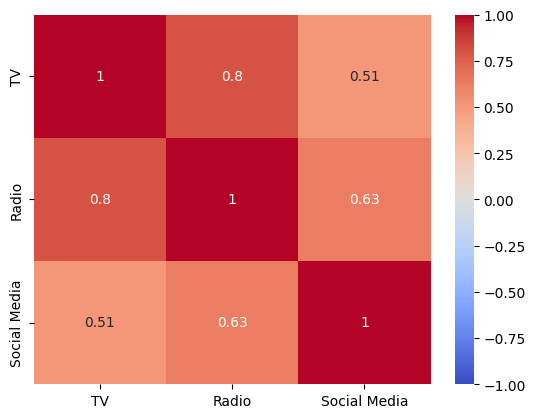

       Variable       VIF
0         const  7.040920
1            TV  2.820621
2         Radio  3.451590
3  Social Media  1.658144


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

df = pd.read_csv('Advert.csv')

# TV is categorical (Low/Medium/High), encode it ordinally
tv_map = {'Low': 1, 'Medium': 2, 'High': 3}
df['TV_encoded'] = df['TV'].map(tv_map)

X = df[['TV_encoded', 'Radio', 'Social Media']].rename(columns={'TV_encoded': 'TV'})

# Correlation matrix
print(X.corr().round(3))
sns.heatmap(X.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.show()

# VIF
X_const = add_constant(X)
vif_data = pd.DataFrame()
vif_data["Variable"] = X_const.columns
vif_data["VIF"] = [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])]
print(vif_data)

In [ ]:
import statsmodels.api as sm
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

y = df['Sales']



# ----------------------------------------------------------------------------
# STEP 3: Build the Multiple Linear Regression model using statsmodels
# ----------------------------------------------------------------------------
# statsmodels does NOT add an intercept automatically (unlike sklearn), so we
# have to add a column of 1's ourselves. Skipping this would force the
# regression line through the origin, which isn't what we want here.

In [ ]:


X_with_const = sm.add_constant(X)

# Fit an Ordinary Least Squares (OLS) model: this finds the coefficients that
# minimize the squared distance between our predictions and the actual Sales values.
model = sm.OLS(y, X_with_const).fit()



# ----------------------------------------------------------------------------
# STEP 4: Evaluate model performance (Adjusted R-squared and p-values)
# ----------------------------------------------------------------------------

In [ ]:

print(model.summary())

# Adjusted R-squared tells us the proportion of variance in Sales explained
# by our model, adjusted for the number of predictors (so adding a useless
# variable doesn't artificially inflate it the way plain R-squared would).
print("\nAdjusted R-squared:", round(model.rsquared_adj, 4))

# P-values tell us whether each predictor's relationship with Sales is
# statistically significant (a common cutoff is p < 0.05).
print("\nP-values for each predictor:")
print(model.pvalues.round(4))



                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.904
Model:                            OLS   Adj. R-squared:                  0.903
Method:                 Least Squares   F-statistic:                     1781.
Date:                Fri, 19 Jun 2026   Prob (F-statistic):          2.10e-288
Time:                        02:12:07   Log-Likelihood:                -2714.2
No. Observations:                 572   AIC:                             5436.
Df Residuals:                     568   BIC:                             5454.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const          -12.2889      3.099     -3.966   

# ----------------------------------------------------------------------------
# STEP 4: Diagnostic plots to validate Linearity, Normality, and Homoscedasticity
# ----------------------------------------------------------------------------

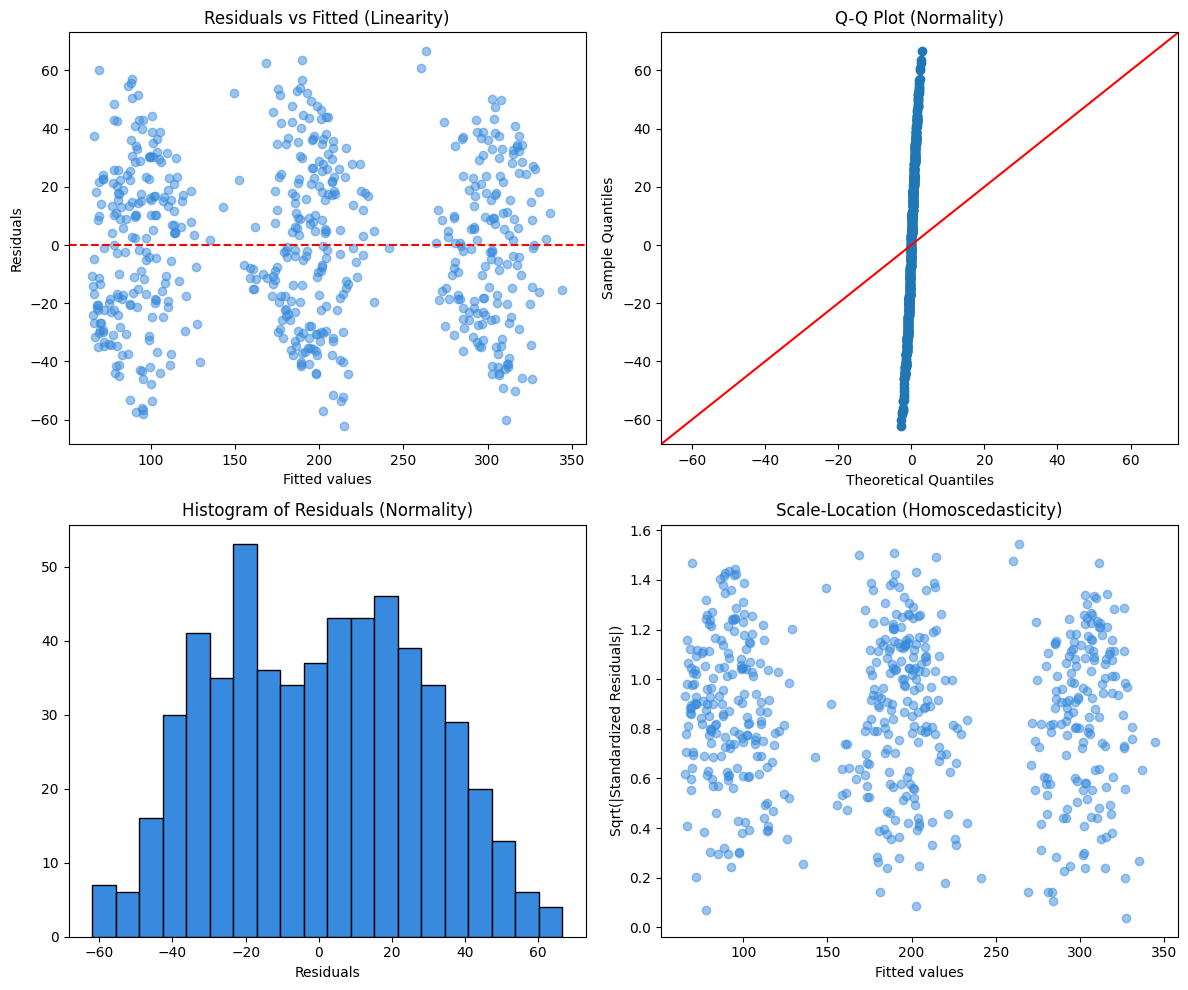


Shapiro-Wilk test p-value: 4e-06


In [ ]:

fitted_values = model.fittedvalues
residuals = model.resid

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 4a. Residuals vs Fitted values: checks LINEARITY.
# If the model's relationship is truly linear, residuals should scatter
# randomly around 0 with no obvious curve or pattern.
axes[0, 0].scatter(fitted_values, residuals, alpha=0.5, color='#378ADD')
axes[0, 0].axhline(y=0, color='red', linestyle='--')
axes[0, 0].set_xlabel('Fitted values')
axes[0, 0].set_ylabel('Residuals')
axes[0, 0].set_title('Residuals vs Fitted (Linearity)')

# 4b. Q-Q plot: checks NORMALITY of residuals.
# If residuals are normally distributed, the points should fall closely
# along the diagonal 45-degree reference line.
sm.qqplot(residuals, line='45', ax=axes[0, 1])
axes[0, 1].set_title('Q-Q Plot (Normality)')

# 4c. Histogram of residuals: a second, more intuitive check for NORMALITY.
# We're looking for a roughly bell-shaped, symmetric distribution centered at 0.
axes[1, 0].hist(residuals, bins=20, edgecolor='black', color='#378ADD')
axes[1, 0].set_title('Histogram of Residuals (Normality)')
axes[1, 0].set_xlabel('Residuals')

# 4d. Scale-Location plot: checks HOMOSCEDASTICITY (constant variance of residuals).
# We want the spread of points to stay roughly even across all fitted values.
# If it fans out or narrows, that signals the variance changes ("heteroscedasticity"),
# which violates a core regression assumption.
standardized_residuals = residuals / residuals.std()
axes[1, 1].scatter(fitted_values, np.sqrt(np.abs(standardized_residuals)), alpha=0.5, color='#378ADD')
axes[1, 1].set_xlabel('Fitted values')
axes[1, 1].set_ylabel('Sqrt(|Standardized Residuals|)')
axes[1, 1].set_title('Scale-Location (Homoscedasticity)')

plt.tight_layout()
plt.savefig('diagnostic_plots.png', dpi=150)
plt.show()

# A statistical backup to the visual Q-Q/histogram check: the Shapiro-Wilk
# test formally tests whether residuals deviate from a normal distribution.
# Note that with large sample sizes, this test can flag very minor, practically
# unimportant deviations as "significant" — so it's best read alongside the plots,
# not as the final word on its own.
shapiro_stat, shapiro_p = stats.shapiro(residuals)
print("\nShapiro-Wilk test p-value:", round(shapiro_p, 6))



# ----------------------------------------------------------------------------
# STEP 5: Interpret coefficients in context
# ----------------------------------------------------------------------------

In [ ]:

# Each coefficient below represents the expected change in Sales for a
# one-unit increase in that predictor, HOLDING THE OTHER PREDICTORS CONSTANT.
print("\nCoefficients:")
print(model.params.round(4))


Coefficients:
const          -12.2889
TV              77.3227
Radio            2.9792
Social Media    -0.1577
dtype: float64
